# 09 — DINOv2 ViT-S/14 Feature Extraction

This notebook extracts pretrained **DINOv2 ViT-S/14** embeddings from the same 2.5D MRI instances used by Notebooks 07 and 08.

**Input:** previous / current / next preprocessed MRI slices  
**Backbone:** `timm/vit_small_patch14_dinov2.lvd142m`  
**Output:** one 384-dimensional embedding per 2.5D instance

These embeddings are the feature-level input for the later **slice-attention → series-attention → study-level MIL** stages.

`SMOKE_TEST=True` is for pipeline validation only.

## 1. Environment and experiment configuration

The DINOv2 model is used as a frozen feature extractor in this notebook. The official timm/Hugging Face configuration for `vit_small_patch14_dinov2.lvd142m` uses a 518×518 input and produces a 384-dimensional pooled feature vector. The 2.5D MRI tensor is therefore resized from 224×224 to 518×518 immediately before feature extraction.

In [1]:
# ==================================================
# 01 — Startup / configuration
# ==================================================

import os
import gc
import glob
import json
import random
import warnings
from functools import lru_cache

import numpy as np
import pandas as pd

print("[1/4] Loading PyTorch...")
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
print(f"      PyTorch {torch.__version__} OK")

print("[2/4] Loading plotting utilities...")
import matplotlib.pyplot as plt
print("      OK")

print("[3/4] Loading timm...")
try:
    import timm
except ImportError as exc:
    raise ImportError(
        "timm is not installed. Add/install timm in the Kaggle environment "
        "and rerun this cell."
    ) from exc
print(f"      timm {timm.__version__} OK")

print("[4/4] Setting configuration...")

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --------------------------------------------------
# DINOv2 configuration
# --------------------------------------------------

MODEL_NAME = "hf_hub:timm/vit_small_patch14_dinov2.lvd142m"

SOURCE_IMAGE_SIZE = 224
DINO_IMAGE_SIZE = 518
EMBED_DIM = 384

# --------------------------------------------------
# Scope
# --------------------------------------------------

# True  -> smoke-test a small number of gold studies
# False -> use all studies represented by the selected scope
SMOKE_TEST = False
SMOKE_STUDY_LIMIT = 5

# Initial gold-only development scope.
# Later, after 03/04 are expanded, change to:
# DATA_SCOPE = "all_indexed"
DATA_SCOPE = "gold"

# Number of 2.5D instances retained per study.
# None = retain all indexed instances for each study.
MAX_INSTANCES_PER_STUDY = 8 if SMOKE_TEST else None

# --------------------------------------------------
# Inference configuration
# --------------------------------------------------

BATCH_SIZE = 4
NUM_WORKERS = 0
USE_AMP = torch.cuda.is_available()

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Smoke test:", SMOKE_TEST)
print("Data scope:", DATA_SCOPE)
print("DINO image size:", DINO_IMAGE_SIZE)
print("Embedding dimension:", EMBED_DIM)
print("Startup complete.")

[1/4] Loading PyTorch...
      PyTorch 2.11.0+cu128 OK
[2/4] Loading plotting utilities...
      OK
[3/4] Loading timm...
      timm 1.0.29 OK
[4/4] Setting configuration...
Device: cuda
GPU: Tesla T4
Smoke test: False
Data scope: gold
DINO image size: 518
Embedding dimension: 384
Startup complete.


## 2. Locate the shared project artifacts

Notebook 09 reuses the same preprocessing and 2.5D artifacts as 07/08:

**03:** preprocessed `.npy` MRI volumes  
**04:** neighbouring-slice 2.5D index  
**05:** study-level folds

The path resolver does not depend on the absolute path stored by Notebook 04; it remaps the stable `processed_data/...` suffix to the currently mounted Notebook 03 output.

In [2]:
# ==================================================
# 02 — Kaggle-safe artifact discovery
# ==================================================

SEARCH_ROOTS = ["/kaggle/input", "/kaggle/working"]

PRUNE_DIRS = {
    "processed_data",
    "train_images",
    "test_images",
    "train_series",
    "test_series",
    "__pycache__",
    ".git"
}


def find_all(filename, max_matches=20):
    matches = []

    for root in SEARCH_ROOTS:
        if not os.path.exists(root):
            continue

        for current, dirs, files in os.walk(root):
            dirs[:] = [
                d for d in dirs
                if d not in PRUNE_DIRS
            ]

            if filename in files:
                matches.append(
                    os.path.join(current, filename)
                )

                if len(matches) >= max_matches:
                    break

    return sorted(set(matches))


def find_processed_roots():
    roots = []

    for root in SEARCH_ROOTS:
        if not os.path.exists(root):
            continue

        for current, dirs, files in os.walk(root):
            keep = []

            for d in dirs:
                full = os.path.join(current, d)

                if d == "processed_data":
                    roots.append(full)
                else:
                    keep.append(d)

            dirs[:] = [
                d for d in keep
                if d not in {
                    "train_images",
                    "test_images",
                    "train_series",
                    "test_series",
                    "__pycache__",
                    ".git"
                }
            ]

    return sorted(
        set(
            os.path.normpath(p)
            for p in roots
            if os.path.isdir(p)
        )
    )


def choose_artifact(filename, preferred_tokens=()):
    candidates = find_all(filename)

    if not candidates:
        return None

    for token in preferred_tokens:
        token = token.lower()

        for path in candidates:
            if token in path.lower():
                return path

    return candidates[0]


# --------------------------------------------------
# Competition data
# --------------------------------------------------

competition_candidates = find_all("train.csv")

competition_candidates = [
    p for p in competition_candidates
    if "rsna" in p.lower() and "knee" in p.lower()
]

if not competition_candidates:
    generic_train = find_all("train.csv")

    if generic_train:
        competition_candidates = generic_train

if not competition_candidates:
    raise FileNotFoundError(
        "RSNA train.csv not found. Attach the competition dataset."
    )

COMP_DIR = os.path.dirname(
    competition_candidates[0]
)

# --------------------------------------------------
# 04 / 05 artifacts
# --------------------------------------------------

cv_index_path = choose_artifact(
    "2p5d_index_with_folds.csv",
    preferred_tokens=(
        "05-cv-splits",
        "05_cv_splits",
        "05_cv",
        "05-cv"
    )
)

if cv_index_path is None:
    raise FileNotFoundError(
        "2p5d_index_with_folds.csv not found. "
        "Attach Notebook 05 output."
    )

processed_roots = find_processed_roots()

print("\nCompetition directory:")
print(COMP_DIR)

print("\nNotebook 05 2.5D + folds:")
print(cv_index_path)

print("\nMounted processed_data directories:")
if processed_roots:
    for root in processed_roots:
        print(root)
else:
    print("NONE FOUND")


Competition directory:
/kaggle/input/competitions/rsna-knee-abnormality-detection

Notebook 05 2.5D + folds:
/kaggle/input/notebooks/shambhavisinha254/05-cv-splits/2p5d_index_with_folds.csv

Mounted processed_data directories:
/kaggle/input/notebooks/shambhavisinha254/03-58-studies/processed_data


In [3]:
# ==================================================
# 03 — Load metadata and define labels
# ==================================================

train = pd.read_csv(
    os.path.join(
        COMP_DIR,
        "train.csv"
    )
)

index_2p5d = pd.read_csv(
    cv_index_path
)

LABEL_COLS = [
    "ACL",
    "MCL",
    "Medial Meniscus",
    "Lateral Meniscus",
    "Medial OA",
    "Lateral OA",
    "PF OA",
    "Effusion",
    "Synovitis",
    "Baker's",
    "Contusion",
    "Fracture"
]

print("Total train studies:", len(train))
print("2.5D rows:", len(index_2p5d))
print(
    "2.5D studies:",
    index_2p5d["StudyInstanceUID"].nunique()
)

gold_all = train.dropna(
    subset=LABEL_COLS
).copy()

print(
    "Complete gold studies:",
    len(gold_all)
)

if "fold" not in index_2p5d.columns:
    raise RuntimeError(
        "Notebook 05 combined index must contain a 'fold' column."
    )

print(
    "Fold rows:",
    len(
        index_2p5d[
            ["StudyInstanceUID", "fold"]
        ].drop_duplicates()
    )
)

Total train studies: 4407
2.5D rows: 10528
2.5D studies: 58
Complete gold studies: 58
Fold rows: 58


In [4]:
# ==================================================
# 04 — Select extraction scope
# ==================================================

if DATA_SCOPE not in {"gold", "all_indexed"}:
    raise ValueError(
        "DATA_SCOPE must be 'gold' or 'all_indexed'."
    )

if DATA_SCOPE == "gold":

    selected_studies = gold_all.copy()

else:

    indexed_ids = (
        index_2p5d["StudyInstanceUID"]
        .drop_duplicates()
        .tolist()
    )

    selected_studies = train[
        train["StudyInstanceUID"].isin(indexed_ids)
    ].copy()

# --------------------------------------------------
# Smoke-test reduction
# --------------------------------------------------

if SMOKE_TEST:

    selected_studies = (
        selected_studies
        .head(SMOKE_STUDY_LIMIT)
        .copy()
    )

print("Extraction scope:", DATA_SCOPE)
print(
    "Selected studies:",
    len(selected_studies)
)

selected_ids = set(
    selected_studies[
        "StudyInstanceUID"
    ]
)

index_selected = index_2p5d[
    index_2p5d[
        "StudyInstanceUID"
    ].isin(selected_ids)
].copy()

print(
    "Selected 2.5D rows before per-study cap:",
    len(index_selected)
)

if index_selected.empty:
    raise RuntimeError(
        "No 2.5D rows are available for the selected studies."
    )

Extraction scope: gold
Selected studies: 58
Selected 2.5D rows before per-study cap: 10528


## 3. Prepare the 2.5D instances

Each index row becomes a three-channel tensor:

`previous slice → channel 1`  
`current slice → channel 2`  
`next slice → channel 3`

DINOv2 receives these three channels as an image. The 224×224 preprocessed volume slices are resized to 518×518 to match the selected DINOv2 model configuration. No labels are used to compute the embedding itself.

In [5]:
# ==================================================
# 05 — Robust processed-volume path resolver
# ==================================================

def resolve_volume_path(original_path):

    original_path = str(original_path)

    # Case 1: path is already valid.
    if os.path.exists(original_path):
        return original_path

    normalized = original_path.replace(
        "\\",
        "/"
    )

    # Case 2: use the path suffix after processed_data/.
    marker = "/processed_data/"

    if marker in normalized:

        suffix = normalized.split(
            marker,
            1
        )[1]

        for root in processed_roots:

            candidate = os.path.join(
                root,
                suffix.replace(
                    "/",
                    os.sep
                )
            )

            if os.path.exists(candidate):
                return candidate

    # Case 3: exact filename lookup inside mounted roots.
    basename = os.path.basename(
        normalized
    )

    for root in processed_roots:

        matches = glob.glob(
            os.path.join(
                root,
                "**",
                basename
            ),
            recursive=True
        )

        if matches:
            return sorted(
                matches
            )[0]

    raise FileNotFoundError(
        "Processed volume could not be resolved.\n\n"
        f"Original path:\n{original_path}\n\n"
        "Mounted processed_data directories:\n"
        + (
            "\n".join(processed_roots)
            if processed_roots
            else "NONE"
        )
    )


# Resolve one row as a pre-flight check.
test_path = resolve_volume_path(
    index_selected[
        "File_Path"
    ].iloc[0]
)

print(
    "Resolved volume:",
    test_path
)

print(
    "Exists:",
    os.path.exists(test_path)
)

Resolved volume: /kaggle/input/notebooks/shambhavisinha254/03-58-studies/processed_data/1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149/1.2.826.0.1.3680043.8.498.10791858932231443712736629517371931282.npy
Exists: True


In [6]:
# ==================================================
# 06 — Limit instances per study and validate schema
# ==================================================

REQUIRED_COLUMNS = [
    "StudyInstanceUID",
    "SeriesInstanceUID",
    "File_Path",
    "Num_Slices",
    "Prev_Slice_Index",
    "Center_Slice_Index",
    "Next_Slice_Index"
]

missing_cols = [
    c for c in REQUIRED_COLUMNS
    if c not in index_selected.columns
]

if missing_cols:
    raise RuntimeError(
        "Missing required 2.5D columns: "
        + str(missing_cols)
    )

rows = []

for study_id, group in index_selected.groupby(
    "StudyInstanceUID",
    sort=True
):

    group = group.reset_index(
        drop=True
    )

    if (
        MAX_INSTANCES_PER_STUDY is not None
        and len(group)
        > MAX_INSTANCES_PER_STUDY
    ):

        group = group.sample(
            n=MAX_INSTANCES_PER_STUDY,
            random_state=SEED
        )

    rows.append(group)

index_selected = pd.concat(
    rows,
    ignore_index=True
)

print(
    "Selected studies:",
    index_selected[
        "StudyInstanceUID"
    ].nunique()
)

print(
    "Selected 2.5D instances:",
    len(index_selected)
)

print(
    "Instances per study:"
)

print(
    index_selected[
        "StudyInstanceUID"
    ].value_counts()
    .describe()
)

Selected studies: 58
Selected 2.5D instances: 10528
Instances per study:
count     58.000000
mean     181.517241
std       82.382983
min       75.000000
25%      124.000000
50%      169.000000
75%      198.750000
max      572.000000
Name: count, dtype: float64


In [7]:
# ==================================================
# 07 — 2.5D tensor loader
# ==================================================

IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32
).view(3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32
).view(3, 1, 1)


@lru_cache(maxsize=8)
def load_volume(path):

    return np.load(
        path,
        mmap_mode="r"
    )


def load_2p5d_tensor(row):

    path = resolve_volume_path(
        row["File_Path"]
    )

    volume = load_volume(
        path
    )

    prev_idx = int(
        row["Prev_Slice_Index"]
    )

    center_idx = int(
        row["Center_Slice_Index"]
    )

    next_idx = int(
        row["Next_Slice_Index"]
    )

    x = np.stack(
        [
            volume[prev_idx],
            volume[center_idx],
            volume[next_idx]
        ],
        axis=0
    ).astype(
        np.float32
    )

    if x.shape[1:] != (
        SOURCE_IMAGE_SIZE,
        SOURCE_IMAGE_SIZE
    ):

        raise ValueError(
            f"Expected "
            f"(3, {SOURCE_IMAGE_SIZE}, {SOURCE_IMAGE_SIZE}), "
            f"got {x.shape}"
        )

    x = torch.from_numpy(
        x
    )

    # Resize to the DINOv2 model's required input size.
    x = F.interpolate(
        x.unsqueeze(0),
        size=(
            DINO_IMAGE_SIZE,
            DINO_IMAGE_SIZE
        ),
        mode="bicubic",
        align_corners=False
    ).squeeze(0)

    x = (
        x - IMAGENET_MEAN
    ) / IMAGENET_STD

    return x

DINOv2 input tensor shape: (3, 518, 518)


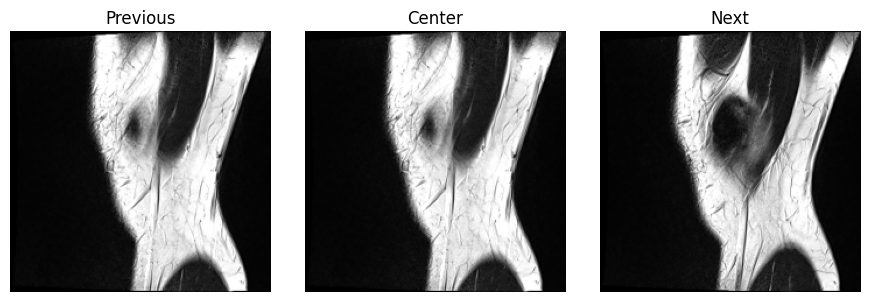

2.5D sanity check: PASSED


In [8]:
# ==================================================
# 08 — Single-instance sanity check
# ==================================================

sample_row = index_selected.iloc[0]

sample_tensor = load_2p5d_tensor(
    sample_row
)

print(
    "DINOv2 input tensor shape:",
    tuple(sample_tensor.shape)
)

if tuple(sample_tensor.shape) != (
    3,
    DINO_IMAGE_SIZE,
    DINO_IMAGE_SIZE
):
    raise RuntimeError(
        "Unexpected DINOv2 input shape."
    )

# Visualize the three channels before ImageNet normalization.
raw_path = resolve_volume_path(
    sample_row["File_Path"]
)

raw_volume = load_volume(
    raw_path
)

raw_triplet = np.stack(
    [
        raw_volume[
            int(sample_row["Prev_Slice_Index"])
        ],
        raw_volume[
            int(sample_row["Center_Slice_Index"])
        ],
        raw_volume[
            int(sample_row["Next_Slice_Index"])
        ]
    ]
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(9, 3)
)

for i, title in enumerate(
    ["Previous", "Center", "Next"]
):

    axes[i].imshow(
        raw_triplet[i],
        cmap="gray"
    )

    axes[i].set_title(
        title
    )

    axes[i].axis("off")

plt.tight_layout()
plt.show()

print(
    "2.5D sanity check: PASSED"
)

## 4. Load pretrained DINOv2

DINOv2 is used here as a **frozen visual feature extractor**, not as a 12-class classifier. The selected ViT-S/14 checkpoint provides a 384-dimensional pooled embedding; those embeddings will later be consumed by the hierarchical MIL model.

In [9]:
# ==================================================
# 09 — Load pretrained DINOv2 ViT-S/14
# ==================================================

MODEL_NAME_FALLBACK = (
    "vit_small_patch14_dinov2.lvd142m"
)

print(
    "Loading:",
    MODEL_NAME
)

try:

    dinov2 = timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=0
    )

except Exception as exc:

    print(
        "\nPrimary model loading failed:"
    )

    print(
        repr(exc)
    )

    print(
        "\nTrying local timm model name..."
    )

    dinov2 = timm.create_model(
        MODEL_NAME_FALLBACK,
        pretrained=True,
        num_classes=0
    )

dinov2 = dinov2.to(
    DEVICE
)

dinov2.eval()

for parameter in dinov2.parameters():
    parameter.requires_grad = False

total_params = sum(
    p.numel()
    for p in dinov2.parameters()
)

trainable_params = sum(
    p.numel()
    for p in dinov2.parameters()
    if p.requires_grad
)

print(
    "Total parameters:",
    total_params
)

print(
    "Trainable parameters:",
    trainable_params
)

print(
    "Backbone frozen:",
    trainable_params == 0
)

print(
    "Model loaded successfully."
)

Loading: hf_hub:timm/vit_small_patch14_dinov2.lvd142m


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Total parameters: 22056192
Trainable parameters: 0
Backbone frozen: True
Model loaded successfully.


In [10]:
# ==================================================
# 10 — DINOv2 forward-pass sanity check
# ==================================================

x = sample_tensor.unsqueeze(
    0
).to(
    DEVICE
)

with torch.inference_mode():

    if USE_AMP:

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            feature = dinov2(x)

    else:

        feature = dinov2(x)

print(
    "Feature shape:",
    tuple(feature.shape)
)

if feature.ndim != 2:
    raise RuntimeError(
        f"Expected [batch, embedding_dim], got {tuple(feature.shape)}"
    )

if feature.shape[-1] != EMBED_DIM:
    raise RuntimeError(
        f"Expected embedding dimension {EMBED_DIM}, "
        f"got {feature.shape[-1]}"
    )

print(
    "DINOv2 feature sanity check: PASSED"
)

Feature shape: (1, 384)
DINOv2 feature sanity check: PASSED


In [11]:
# ==================================================
# 11 — Batch feature extraction
# ==================================================

feature_rows = []
feature_chunks = []

dinov2.eval()

for start in range(
    0,
    len(index_selected),
    BATCH_SIZE
):

    batch_df = index_selected.iloc[
        start:
        start + BATCH_SIZE
    ].copy()

    tensors = [
        load_2p5d_tensor(
            row
        )
        for _, row in batch_df.iterrows()
    ]

    batch_x = torch.stack(
        tensors,
        dim=0
    ).to(
        DEVICE,
        non_blocking=True
    )

    with torch.inference_mode():

        if USE_AMP:

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                batch_features = dinov2(
                    batch_x
                )

        else:

            batch_features = dinov2(
                batch_x
            )

    batch_features = (
        batch_features
        .float()
        .cpu()
        .numpy()
    )

    if batch_features.shape[1] != EMBED_DIM:
        raise RuntimeError(
            "Unexpected embedding dimension: "
            + str(batch_features.shape)
        )

    feature_chunks.append(
        batch_features
    )

    feature_rows.append(
        batch_df
    )

    if (
        (start // BATCH_SIZE) % 10 == 0
        or
        start + BATCH_SIZE
        >= len(index_selected)
    ):

        print(
            f"Processed "
            f"{min(start + BATCH_SIZE, len(index_selected))}"
            f"/{len(index_selected)} instances"
        )

    del batch_x
    del batch_features

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

features = np.concatenate(
    feature_chunks,
    axis=0
)

feature_metadata = pd.concat(
    feature_rows,
    ignore_index=True
)

print(
    "\nEmbeddings shape:",
    features.shape
)

print(
    "Metadata rows:",
    len(feature_metadata)
)

if len(features) != len(feature_metadata):
    raise RuntimeError(
        "Embedding count and metadata count do not match."
    )

print(
    "Extraction completed successfully."
)

Processed 4/10528 instances
Processed 44/10528 instances
Processed 84/10528 instances
Processed 124/10528 instances
Processed 164/10528 instances
Processed 204/10528 instances
Processed 244/10528 instances
Processed 284/10528 instances
Processed 324/10528 instances
Processed 364/10528 instances
Processed 404/10528 instances
Processed 444/10528 instances
Processed 484/10528 instances
Processed 524/10528 instances
Processed 564/10528 instances
Processed 604/10528 instances
Processed 644/10528 instances
Processed 684/10528 instances
Processed 724/10528 instances
Processed 764/10528 instances
Processed 804/10528 instances
Processed 844/10528 instances
Processed 884/10528 instances
Processed 924/10528 instances
Processed 964/10528 instances
Processed 1004/10528 instances
Processed 1044/10528 instances
Processed 1084/10528 instances
Processed 1124/10528 instances
Processed 1164/10528 instances
Processed 1204/10528 instances
Processed 1244/10528 instances
Processed 1284/10528 instances
Proces

## 5. Save embeddings and metadata

Embeddings are stored as `float16` to reduce disk usage. The metadata keeps the study/series identifiers and slice indices needed by later MIL notebooks to reconstruct the hierarchy:

**embedding → slice instance → series → study**

In [12]:
# ==================================================
# 12 — Build final embedding metadata
# ==================================================

feature_metadata = feature_metadata.copy()

feature_metadata.insert(
    0,
    "Embedding_Index",
    np.arange(
        len(feature_metadata)
    )
)

# Keep the most useful columns first.
preferred_columns = [
    "Embedding_Index",
    "StudyInstanceUID",
    "SeriesInstanceUID",
    "fold",
    "Anatomical_Plane",
    "Fluid_Sensitive",
    "Fat_Suppression",
    "File_Path",
    "Num_Slices",
    "Prev_Slice_Index",
    "Center_Slice_Index",
    "Next_Slice_Index"
]

existing_preferred = [
    c for c in preferred_columns
    if c in feature_metadata.columns
]

remaining_columns = [
    c for c in feature_metadata.columns
    if c not in existing_preferred
]

feature_metadata = feature_metadata[
    existing_preferred
    + remaining_columns
]

print(
    "Embedding metadata columns:"
)

print(
    feature_metadata.columns.tolist()
)

display(
    feature_metadata.head()
)

Embedding metadata columns:
['Embedding_Index', 'StudyInstanceUID', 'SeriesInstanceUID', 'fold', 'Anatomical_Plane', 'Fluid_Sensitive', 'Fat_Suppression', 'File_Path', 'Num_Slices', 'Prev_Slice_Index', 'Center_Slice_Index', 'Next_Slice_Index']


,Embedding_Index,StudyInstanceUID,SeriesInstanceUID,fold,Anatomical_Plane,Fluid_Sensitive,Fat_Suppression,File_Path,Num_Slices,Prev_Slice_Index,Center_Slice_Index,Next_Slice_Index
0,0,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.10791858932231443712...,0,Sagittal,0,0,/kaggle/input/notebooks/shambhavisinha254/03-5...,36,0,0,1
1,1,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.10791858932231443712...,0,Sagittal,0,0,/kaggle/input/notebooks/shambhavisinha254/03-5...,36,0,1,2
2,2,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.10791858932231443712...,0,Sagittal,0,0,/kaggle/input/notebooks/shambhavisinha254/03-5...,36,1,2,3
3,3,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.10791858932231443712...,0,Sagittal,0,0,/kaggle/input/notebooks/shambhavisinha254/03-5...,36,2,3,4
4,4,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.10791858932231443712...,0,Sagittal,0,0,/kaggle/input/notebooks/shambhavisinha254/03-5...,36,3,4,5


In [13]:
# ==================================================
# 13 — Save embeddings + metadata
# ==================================================

OUTPUT_DIR = "/kaggle/working"

embedding_path = os.path.join(
    OUTPUT_DIR,
    "dinov2_vits14_embeddings_float16.npy"
)

metadata_path = os.path.join(
    OUTPUT_DIR,
    "dinov2_vits14_embedding_metadata.csv"
)

manifest_path = os.path.join(
    OUTPUT_DIR,
    "dinov2_vits14_embedding_manifest.json"
)

# Float16 is sufficient for stored feature vectors
# and substantially reduces artifact size.
np.save(
    embedding_path,
    features.astype(
        np.float16
    )
)

feature_metadata.to_csv(
    metadata_path,
    index=False
)

manifest = {
    "model_name": MODEL_NAME,
    "embedding_dim": int(EMBED_DIM),
    "input_size": [
        3,
        DINO_IMAGE_SIZE,
        DINO_IMAGE_SIZE
    ],
    "source_size": [
        3,
        SOURCE_IMAGE_SIZE,
        SOURCE_IMAGE_SIZE
    ],
    "data_scope": DATA_SCOPE,
    "smoke_test": bool(SMOKE_TEST),
    "num_studies": int(
        feature_metadata[
            "StudyInstanceUID"
        ].nunique()
    ),
    "num_embeddings": int(
        len(features)
    ),
    "dtype": "float16",
    "seed": SEED
}

with open(
    manifest_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )

print(
    "Saved:",
    embedding_path
)

print(
    "Saved:",
    metadata_path
)

print(
    "Saved:",
    manifest_path
)

Saved: /kaggle/working/dinov2_vits14_embeddings_float16.npy
Saved: /kaggle/working/dinov2_vits14_embedding_metadata.csv
Saved: /kaggle/working/dinov2_vits14_embedding_manifest.json


## 6. Embedding diagnostics

These checks confirm that embeddings are finite, have the expected dimensionality, and are not accidentally identical across all MRI instances. The diagnostics are sanity checks, not model-performance metrics.

In [14]:
# ==================================================
# 14 — Embedding quality checks
# ==================================================

loaded_embeddings = np.load(
    embedding_path,
    mmap_mode="r"
)

print(
    "Saved embedding shape:",
    loaded_embeddings.shape
)

print(
    "Saved dtype:",
    loaded_embeddings.dtype
)

print(
    "Finite:",
    np.isfinite(
        loaded_embeddings
    ).all()
)

embedding_float32 = np.asarray(
    loaded_embeddings
).astype(
    np.float32
)

embedding_std = np.std(
    embedding_float32,
    axis=0
)

print(
    "Mean feature std:",
    float(
        embedding_std.mean()
    )
)

print(
    "Minimum feature std:",
    float(
        embedding_std.min()
    )
)

print(
    "Maximum feature std:",
    float(
        embedding_std.max()
    )
)

print(
    "Maximum absolute embedding value:",
    float(
        np.max(
            np.abs(
                embedding_float32
            )
        )
    )
)

if loaded_embeddings.shape != (
    len(feature_metadata),
    EMBED_DIM
):
    raise RuntimeError(
        "Saved embedding shape does not "
        "match metadata."
    )

if not np.isfinite(
    embedding_float32
).all():
    raise RuntimeError(
        "Non-finite values detected in embeddings."
    )

print(
    "\nEmbedding integrity checks: PASSED"
)

Saved embedding shape: (10528, 384)
Saved dtype: float16
Finite: True
Mean feature std: 1.3080826997756958
Minimum feature std: 0.6008260250091553
Maximum feature std: 2.5850493907928467
Maximum absolute embedding value: 11.9453125

Embedding integrity checks: PASSED


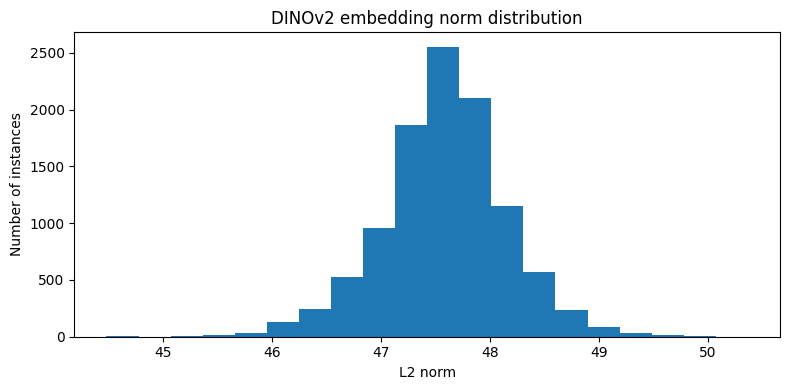

Mean embedding norm: 47.5840950012207
Std embedding norm: 0.567584753036499


In [15]:
# ==================================================
# 15 — Embedding norm visualization
# ==================================================

embedding_norms = np.linalg.norm(
    np.asarray(
        loaded_embeddings
    ).astype(np.float32),
    axis=1
)

plt.figure(
    figsize=(8, 4)
)

plt.hist(
    embedding_norms,
    bins=20
)

plt.xlabel(
    "L2 norm"
)

plt.ylabel(
    "Number of instances"
)

plt.title(
    "DINOv2 embedding norm distribution"
)

plt.tight_layout()
plt.show()

print(
    "Mean embedding norm:",
    float(
        embedding_norms.mean()
    )
)

print(
    "Std embedding norm:",
    float(
        embedding_norms.std()
    )
)

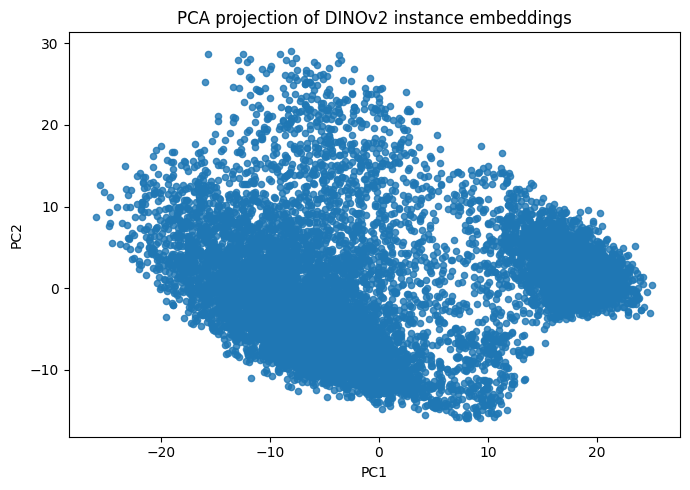

Explained variance ratio: [0.21029721 0.08225896]


In [16]:
# ==================================================
# 16 — PCA diagnostic
# ==================================================

from sklearn.decomposition import PCA

pca_input = np.asarray(
    loaded_embeddings
).astype(
    np.float32
)

# PCA is only a diagnostic visualization.
# The saved embeddings themselves are NOT reduced.
n_components = min(
    2,
    pca_input.shape[0],
    pca_input.shape[1]
)

if n_components == 2:

    pca = PCA(
        n_components=2,
        random_state=SEED
    )

    embedding_2d = pca.fit_transform(
        pca_input
    )

    plt.figure(
        figsize=(7, 5)
    )

    plt.scatter(
        embedding_2d[:, 0],
        embedding_2d[:, 1],
        s=20,
        alpha=0.8
    )

    plt.xlabel(
        "PC1"
    )

    plt.ylabel(
        "PC2"
    )

    plt.title(
        "PCA projection of DINOv2 instance embeddings"
    )

    plt.tight_layout()
    plt.show()

    print(
        "Explained variance ratio:",
        pca.explained_variance_ratio_
    )

else:

    print(
        "PCA visualization skipped: fewer than 2 samples."
    )

In [17]:
# ==================================================
# 17 — Coverage summary
# ==================================================

coverage_summary = {
    "studies": int(
        feature_metadata[
            "StudyInstanceUID"
        ].nunique()
    ),
    "series": int(
        feature_metadata[
            "SeriesInstanceUID"
        ].nunique()
    ),
    "2p5d_instances": int(
        len(feature_metadata)
    ),
    "embedding_dimension": int(
        EMBED_DIM
    ),
    "smoke_test": bool(
        SMOKE_TEST
    ),
    "data_scope": DATA_SCOPE
}

coverage_df = pd.DataFrame(
    [coverage_summary]
)

display(
    coverage_df
)

coverage_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "dinov2_vits14_coverage_summary.csv"
    ),
    index=False
)

,studies,series,2p5d_instances,embedding_dimension,smoke_test,data_scope
0,58,336,10528,384,False,gold


In [18]:
# ==================================================
# 18 — Reproducibility checklist
# ==================================================

expected_outputs = [
    "dinov2_vits14_embeddings_float16.npy",
    "dinov2_vits14_embedding_metadata.csv",
    "dinov2_vits14_embedding_manifest.json",
    "dinov2_vits14_coverage_summary.csv"
]

print(
    "DINOv2 experiment artifacts:"
)

for name in expected_outputs:

    path = os.path.join(
        OUTPUT_DIR,
        name
    )

    status = (
        "OK  "
        if os.path.exists(path)
        else "MISS"
    )

    print(
        status,
        name
    )

print(
    "\nNotebook 09 feature extraction completed."
)

print(
    "These embeddings are ready for the later "
    "slice/series/study MIL stages."
)

print(
    "\nFor the project report, remember to disclose "
    "any LLM/external-code assistance according to the "
    "course academic-integrity requirements."
)

DINOv2 experiment artifacts:
OK   dinov2_vits14_embeddings_float16.npy
OK   dinov2_vits14_embedding_metadata.csv
OK   dinov2_vits14_embedding_manifest.json
OK   dinov2_vits14_coverage_summary.csv

Notebook 09 feature extraction completed.
These embeddings are ready for the later slice/series/study MIL stages.

For the project report, remember to disclose any LLM/external-code assistance according to the course academic-integrity requirements.
